# Model Training Notebook
This notebook trains models for Diabetic Risk Assessment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import json
import os

os.makedirs('../models', exist_ok=True)


In [2]:
# Load Data
df = pd.read_csv('../data/diabetes.csv')
df.head()

,Gender,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72,35,0,33.6,0.627,50,1
1,1,1,85,66,29,0,26.6,0.351,31,0
2,0,8,183,64,0,0,23.3,0.672,32,1
3,0,1,89,66,23,94,28.1,0.167,21,0
4,0,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Replace invalid zero values with medians
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    median = df[col].median()
    df[col] = df[col].fillna(median)


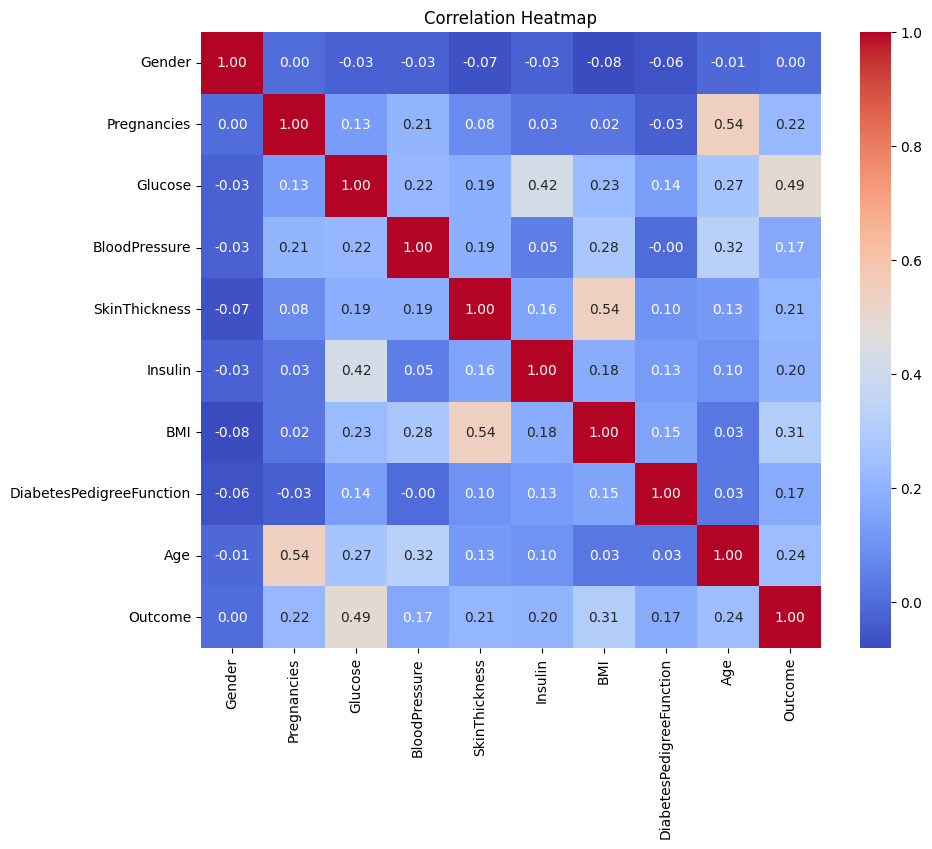

In [4]:
# EDA
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

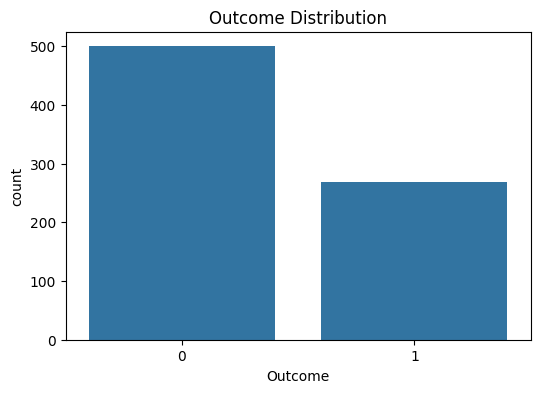

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Outcome Distribution')
plt.show()

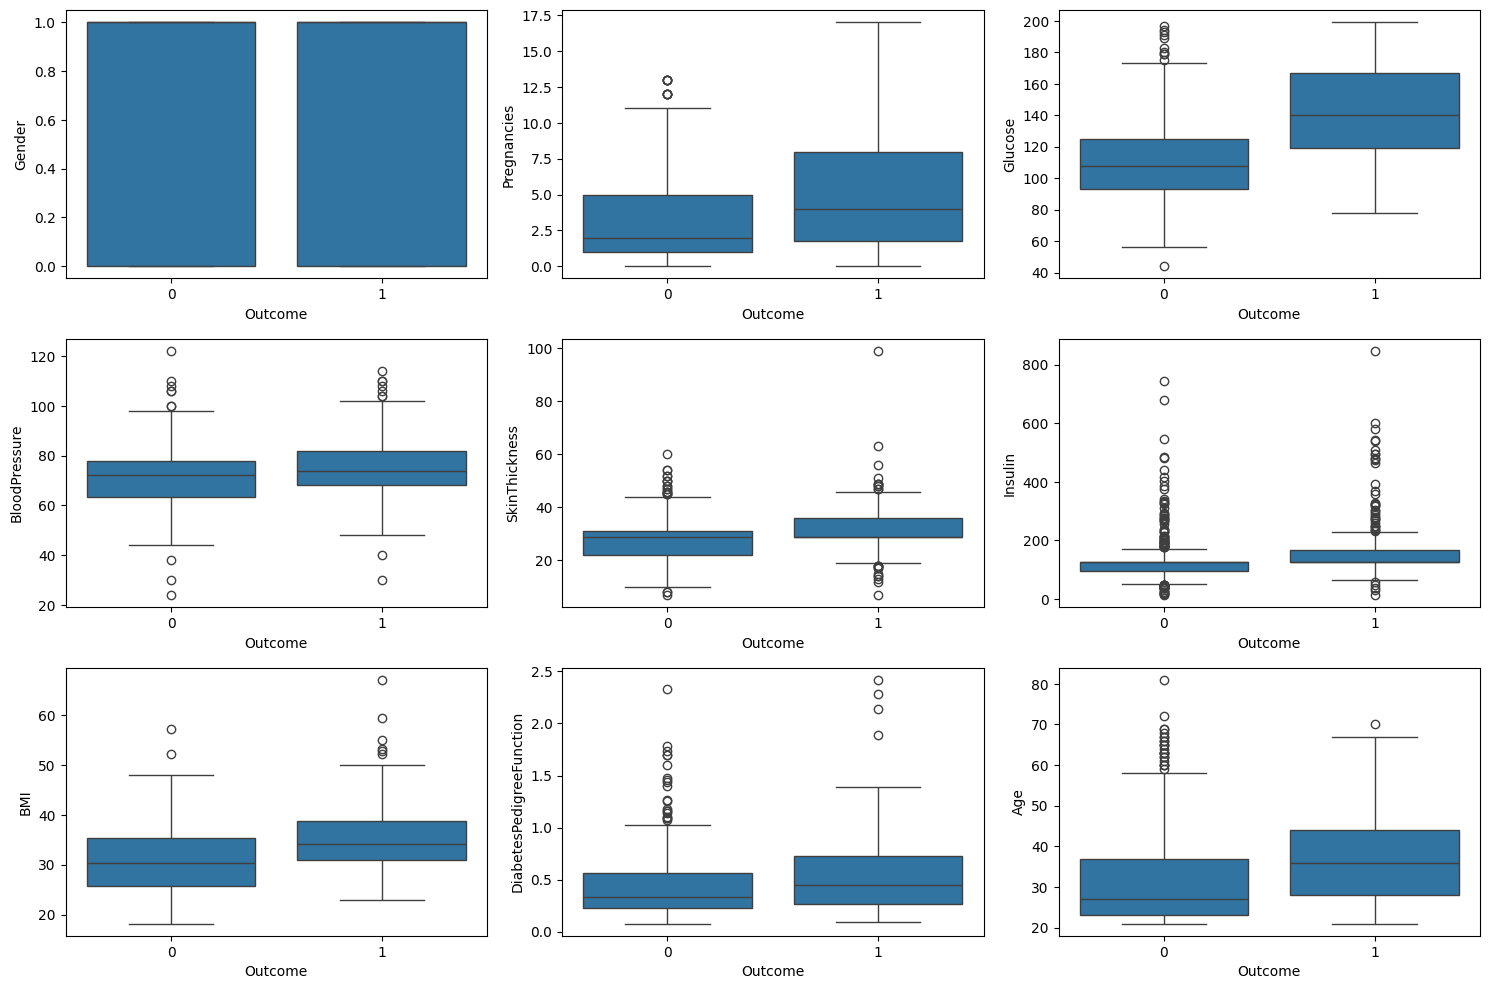

In [6]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Outcome', y=col, data=df)
plt.tight_layout()
plt.show()

In [7]:
# Preprocessing
X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, '../models/scaler.pkl')

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
# Model Training
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

results = {}
best_model = None
best_roc_auc = 0
best_model_name = ''
best_accuracy = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f'--- {name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(f'ROC-AUC: {roc_auc:.4f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    if roc_auc > best_roc_auc:
        best_roc_auc = roc_auc
        best_model = model
        best_model_name = name
        best_accuracy = acc

--- RandomForest ---
Accuracy: 0.7532
ROC-AUC: 0.8316
Confusion Matrix:
[[78 21]
 [17 38]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.64      0.69      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154

--- LogisticRegression ---
Accuracy: 0.7597
ROC-AUC: 0.8230
Confusion Matrix:
[[83 16]
 [21 34]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        99
           1       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154

--- GradientBoosting ---
Accuracy: 0.7532
ROC-AUC: 0.8158
Confusion Matrix:
[[78 21]
 [17 38]]
Classification Re

In [9]:
# Save Best Model and Info
joblib.dump(best_model, '../models/best_model.pkl')

model_info = {
    'model_name': best_model_name,
    'accuracy': best_accuracy,
    'roc_auc': best_roc_auc,
    'feature_names': list(X.columns)
}

with open('../models/model_info.json', 'w') as f:
    json.dump(model_info, f)

print(f'Best model saved: {best_model_name} with ROC-AUC {best_roc_auc:.4f}')

Best model saved: RandomForest with ROC-AUC 0.8316
